# 23 August

In [1]:
import os
import sys
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from configs.configs import ErrorEnum
from utils.error_report import get_error_from_list, get_error_report
from utils import lla_to_enu, lla_to_ned
from decimal import Decimal, getcontext
import scipy.stats as stats
from numpy.linalg import norm

from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../../../"
uav_root_path = os.path.join(root_path, "data/UAV")

vo_path = os.path.join(uav_root_path, "log0022/run/mpa/qvio/data.csv")
vo_extended_path = os.path.join(uav_root_path, "log0022/run/mpa/qvio_extended/data_modified.csv")
gps_path = os.path.join(uav_root_path, "log0022/px4/09_00_22_estimator_global_position_0.csv")

In [3]:
vo_df = pd.read_csv(vo_path)
vo_ex_df = pd.read_csv(vo_extended_path)
gps_df = pd.read_csv(gps_path)

In [4]:
ex_df_columns = ['timestamp_ns', 'T_imu_wrt_vio_x', 'T_imu_wrt_vio_y', 'T_imu_wrt_vio_z', 
                 'roll(rad)', 'pitch(rad)', 'yaw(rad)', 'gyro_bias_x', 'gyro_bias_y', 'gyro_bias_z', 
                 'accl_bias_x', 'accl_bias_y', 'accl_bias_z', ' n_feature_points', ' n_total_features', 'T_cam_wrt_imu_y']
vo_ex_df = vo_ex_df[ex_df_columns]
vo_ex_df.rename(columns={' n_feature_points': 'n_feature_points', ' n_total_features': 'n_total_features'}, inplace=True)
ex_df_columns = [str(c).replace(' ', '') for c in ex_df_columns]

In [5]:
# Convert lla into North-East-Down coordinate in meter

def get_ned_coord(df):    
    origin = df[['lon', 'lat', 'alt']].iloc[0].values
    ned_pose = lla_to_ned(df[['lon', 'lat', 'alt']].values.T, origin).T
    df = pd.concat([
        df,
        pd.DataFrame(ned_pose, columns=['north', 'east', 'down'])
    ], axis=1)
    return df

gps_df = get_ned_coord(gps_df)

In [6]:
gps_columns = ['north', 'east', 'down']
vo_columns = ['position[0]', 'position[1]', 'position[2]']
vo_columns = ['T_imu_wrt_vio_x(m)', 'T_imu_wrt_vio_y(m)', 'T_imu_wrt_vio_z(m)']

In [7]:
def Rz(theta):
    """rotation matrix around z-axis
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, s, 0],
        [-s, c, 0],
        [0, 0, 1]
    ])

In [24]:
rotation = Rz(np.radians(100))

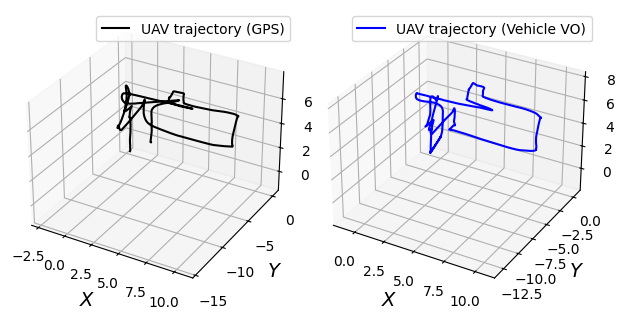

In [25]:
fig = plt.figure()

ax1 = fig.add_subplot(121, projection='3d')
x, y, z = gps_df[['north', 'east', 'down']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (GPS)', color='black')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

ax2 = fig.add_subplot(122, projection='3d')
x, y, z = rotation @ vo_df[vo_columns].values.T 
ax2.plot(x, y, -z, label='UAV trajectory (Vehicle VO)', color='blue')
ax2.legend()
ax2.set_xlabel('$X$', fontsize=14)
ax2.set_ylabel('$Y$', fontsize=14)
ax2.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

In [26]:
duration = (vo_df["timestamp(ns)"].iloc[-1] - vo_df["timestamp(ns)"].iloc[0]) / 1_000_000_000
print(f"Length of the flight: {round(np.linalg.norm(vo_df[vo_columns].values.T), 2)}m")
print(f"Length of the flight: {round(duration, 2)}seconds")

Length of the flight: 355.76m
Length of the flight: 75.95seconds


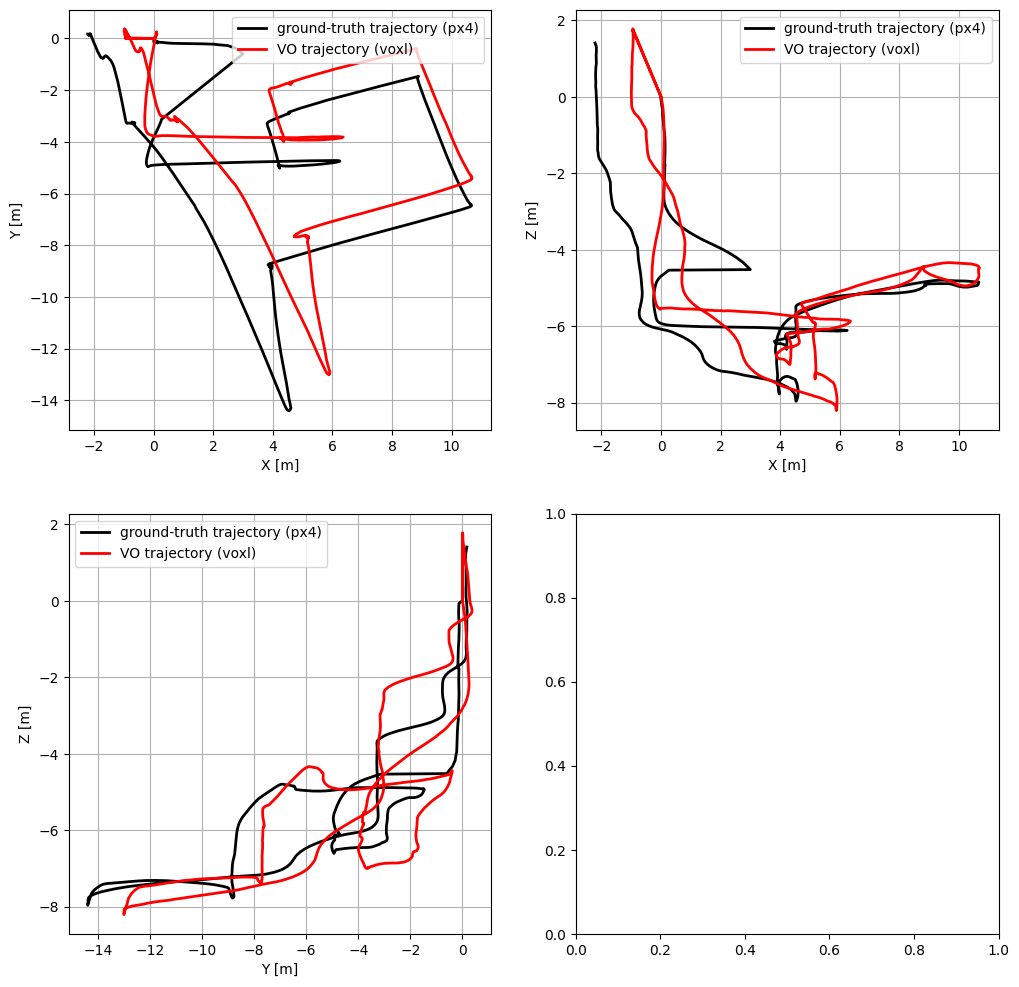

In [27]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(12, 12))
x, y, z = gps_df[['north', 'east', 'down']].values.T
ax1[0].plot(x, y, lw=2, label='ground-truth trajectory (px4)', color='black')
x, y, z = rotation @ vo_df[vo_columns].values.T 
ax1[0].plot(x, y, lw=2, label='VO trajectory (voxl)', color='red')
ax1[0].set_xlabel('X [m]')
ax1[0].set_ylabel('Y [m]')
ax1[0].legend()
ax1[0].grid()

x, y, z = gps_df[['north', 'east', 'down']].values.T
ax1[1].plot(x, z, lw=2, label='ground-truth trajectory (px4)', color='black')
x, y, z = rotation @ vo_df[vo_columns].values.T 
ax1[1].plot(x, z, lw=2, label='VO trajectory (voxl)', color='red')
ax1[1].set_xlabel('X [m]')
ax1[1].set_ylabel('Z [m]')
ax1[1].legend()
ax1[1].grid()

x, y, z = gps_df[['north', 'east', 'down']].values.T
ax2[0].plot(y, z, lw=2, label='ground-truth trajectory (px4)', color='black')
x, y, z = rotation @ vo_df[vo_columns].values.T 
ax2[0].plot(y, z, lw=2, label='VO trajectory (voxl)', color='red')
ax2[0].set_xlabel('Y [m]')
ax2[0].set_ylabel('Z [m]')
ax2[0].legend()
ax2[0].grid()

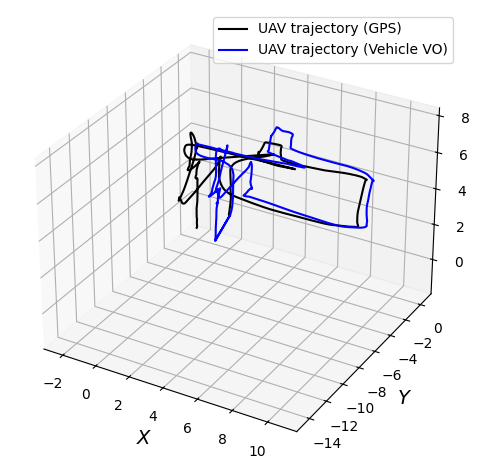

In [28]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')
x, y, z = gps_df[['north', 'east', 'down']].values.T
ax1.plot(x, y, -z, label='UAV trajectory (GPS)', color='black')
x, y, z = rotation @ vo_df[vo_columns].values.T 
ax1.plot(x, y, -z, label='UAV trajectory (Vehicle VO)', color='blue')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

In [29]:
gps_index = vo_ex_df["timestamp_ns"].apply(lambda x: np.argmin(np.abs(gps_df["timestamp"] - x/1000)))

In [30]:
vo = (rotation @ vo_df[vo_columns].values.T).T[:, :2].T
gps = gps_df.iloc[gps_index][['north', 'east']].values.T

In [31]:
print(f"MAE (in 2D): {mean_absolute_error(gps.T, vo.T)}m")
print(f"RMSE (in 2D): {root_mean_squared_error(gps, vo)}m")

MAE (in 2D): 1.1178498178904492m
RMSE (in 2D): 1.3050609830726947m


In [32]:
vo_ex_smapling_rate = vo_ex_df.shape[0] / ((vo_ex_df['timestamp_ns'].iloc[-1] - vo_ex_df['timestamp_ns'].iloc[0]) / 1_000_000_000)
gps_sampling_rate = gps_df.shape[0] / ((gps_df['timestamp'].iloc[-1] - gps_df['timestamp'].iloc[0]) / 1_000_000)
print(f"Vehicle Odometry sampling rate: {vo_ex_smapling_rate}Hz")
print(f"GPS sampling rate: {gps_sampling_rate}Hz")

Vehicle Odometry sampling rate: 30.01966915582794Hz
GPS sampling rate: 99.86609849983402Hz


In [33]:
vo_ex_df

,timestamp_ns,T_imu_wrt_vio_x,T_imu_wrt_vio_y,T_imu_wrt_vio_z,roll(rad),pitch(rad),yaw(rad),gyro_bias_x,gyro_bias_y,gyro_bias_z,accl_bias_x,accl_bias_y,accl_bias_z,n_feature_points,n_total_features,T_cam_wrt_imu_y
0,591887965521,0.000,0.000,0.000,-0.001,-0.002,0.000,0.065,-0.014,0.013,0.000,0.650,1.571,2,2,28
1,591917592177,0.000,0.000,0.000,-0.001,-0.002,0.000,0.065,-0.014,0.013,0.000,0.650,1.571,2,2,28
2,591947243467,0.000,0.000,0.000,-0.001,-0.002,0.000,0.065,-0.014,0.013,0.000,0.650,1.571,2,2,28
3,591986811987,0.000,0.000,0.000,-0.001,-0.002,0.000,0.065,-0.014,0.013,0.000,0.650,1.571,2,2,28
4,592016502824,0.000,0.000,0.000,-0.001,-0.002,0.000,0.065,-0.014,0.013,0.000,0.650,1.571,2,2,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,667709213058,0.152,-0.935,1.737,0.135,0.177,0.463,0.065,-0.014,0.013,-0.001,0.649,1.572,2,2,28
2276,667738925604,0.152,-0.935,1.737,0.135,0.177,0.463,0.065,-0.014,0.013,-0.001,0.649,1.572,2,2,28
2277,667768826113,0.152,-0.935,1.737,0.135,0.177,0.463,0.065,-0.014,0.013,-0.001,0.649,1.572,2,2,28
2278,667808457970,0.152,-0.935,1.737,0.135,0.177,0.463,0.065,-0.014,0.013,-0.001,0.649,1.572,2,2,28


In [34]:
t_vo = vo_ex_df.loc[(rotation @ vo_ex_df[
                     ["T_imu_wrt_vio_x", "T_imu_wrt_vio_y", "T_imu_wrt_vio_z"]
                     ].values.T)[2, :] < 0]['timestamp_ns'].iloc[0] / 1000
t_gps = gps_df.iloc[gps_index].loc[gps_df.iloc[gps_index][['north', 'east', 'down']].values[:, 2] < 0]['timestamp'].iloc[0]
delay = (t_vo - t_gps) / 1_000_000
print(f"The delay is {delay} seconds")

The delay is 0.5704162869999408 seconds


In [35]:
(690431927.593 - 688700586) / 1_000_000

1.7313415930000544

In [36]:
vo_ex_df.head()

,timestamp_ns,T_imu_wrt_vio_x,T_imu_wrt_vio_y,T_imu_wrt_vio_z,roll(rad),pitch(rad),yaw(rad),gyro_bias_x,gyro_bias_y,gyro_bias_z,accl_bias_x,accl_bias_y,accl_bias_z,n_feature_points,n_total_features,T_cam_wrt_imu_y
0,591887965521,0.0,0.0,0.0,-0.001,-0.002,0.0,0.065,-0.014,0.013,0.0,0.65,1.571,2,2,28
1,591917592177,0.0,0.0,0.0,-0.001,-0.002,0.0,0.065,-0.014,0.013,0.0,0.65,1.571,2,2,28
2,591947243467,0.0,0.0,0.0,-0.001,-0.002,0.0,0.065,-0.014,0.013,0.0,0.65,1.571,2,2,28
3,591986811987,0.0,0.0,0.0,-0.001,-0.002,0.0,0.065,-0.014,0.013,0.0,0.65,1.571,2,2,28
4,592016502824,0.0,0.0,0.0,-0.001,-0.002,0.0,0.065,-0.014,0.013,0.0,0.65,1.571,2,2,28


In [37]:
def plot_trajectory_and_feature_points():

    labels = ['X', 'Y', 'Z']
    for axis in range(3):
        fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), gridspec_kw={'height_ratios': [2, 1]})
        
        plt.suptitle(f"Quadocopter GPS trajectory vs Vehicle trajectory in {labels[axis]}-axis and number of feature points", fontsize=14)
        
        index = vo_ex_df['timestamp_ns'].values
        x = gps_df.iloc[gps_index][['north', 'east', 'down']].values[:, axis]
        axs[0].plot(index, x, label='Ground-truth trajectory (px4)', color='black')
        
        x = (rotation @ vo_ex_df[["T_imu_wrt_vio_x", "T_imu_wrt_vio_y", "T_imu_wrt_vio_z"]].values.T)[axis, :]
        axs[0].plot(index, x, label='Vehicle odometory trajectory (voxl)', color='red')
        
        axs[0].set_xlabel('Timestamp(ns)')
        axs[0].set_ylabel(f'{labels[axis]} [m]')
        
        num_features = vo_ex_df['T_cam_wrt_imu_y'].values
        axs[1].plot(index, num_features, label='Number of feature points (PTS)', color='red')
        
        axs[1].set_xlabel('Timestamp(ns)')
        axs[1].set_ylabel('# of features')
        
        axs[0].legend(loc=4)
        axs[1].legend(loc=4)
        fig.tight_layout()
        plt.show()

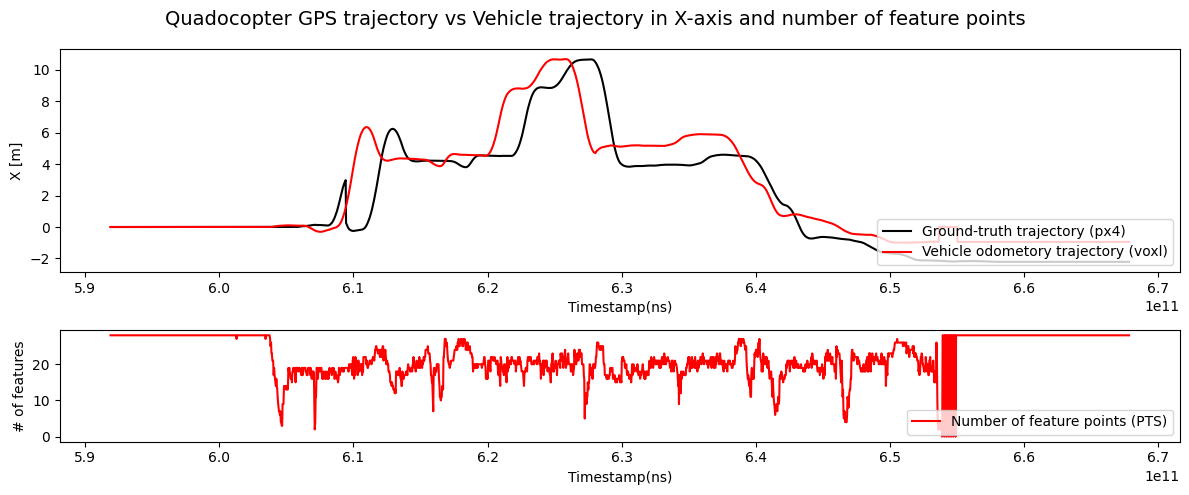

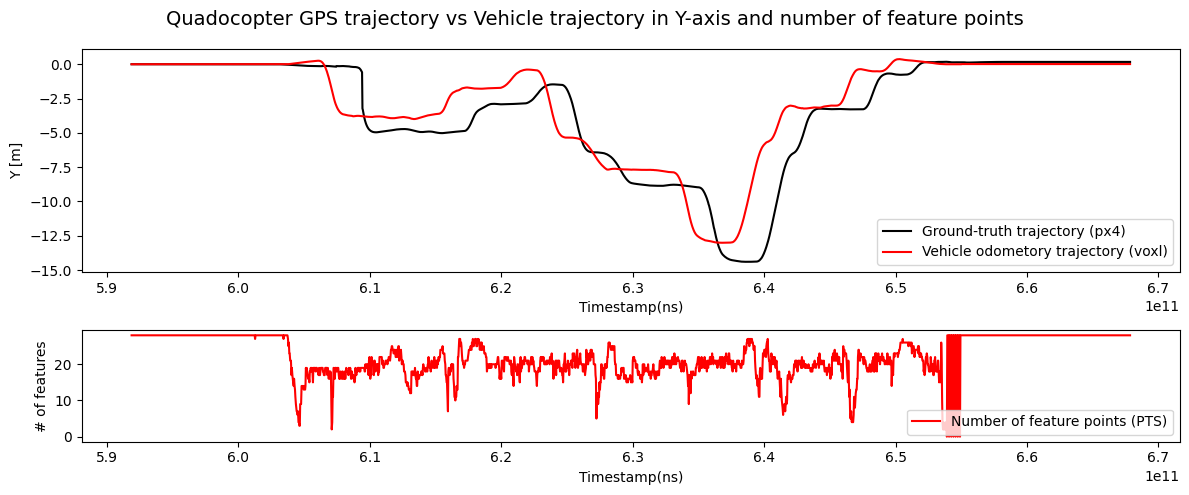

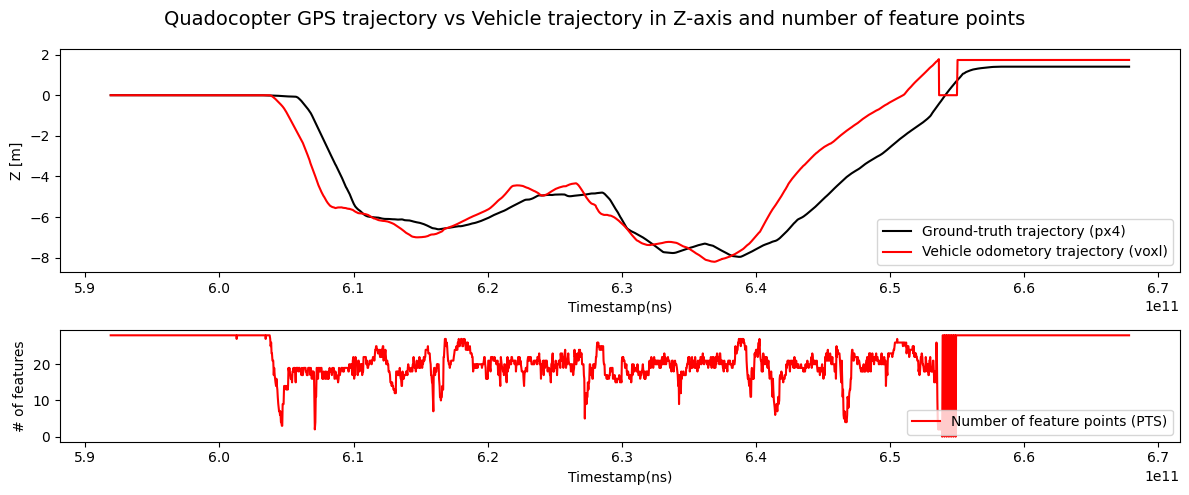

In [38]:
plot_trajectory_and_feature_points()